In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT => temperature
# V => vacuum
# AP => pressure
# RH => humidity

# PE => produced energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [8]:
# Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
df.shape

(9568, 5)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

In [12]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [13]:
type(X_train_scaled)

numpy.ndarray

In [14]:
type(y_train)
y_train.shape

(7654,)

In [15]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [16]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### Deep Learning

In [17]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
            
            nn.Linear(6, 6),
            nn.ReLU(),
    
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [18]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [19]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 
    
    for xb, yb in train_loader:
        optimizer.zero_grad()
        
        outputs = model(xb) 
        loss = crietrion(outputs, yb) 
        loss.backward() 
        optimizer.step() 
        
        running_loss += loss.item() 

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): 
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/100 ==> train loss = 206194.49615885416 & val loss = 204621.609375
epoch 2/100 ==> train loss = 200359.38033854167 & val loss = 193015.203125
epoch 3/100 ==> train loss = 179615.81490885417 & val loss = 162231.703125
epoch 4/100 ==> train loss = 139722.85247395834 & val loss = 115107.984375
epoch 5/100 ==> train loss = 90460.84210611979 & val loss = 67147.046875
epoch 6/100 ==> train loss = 49294.06258138021 & val loss = 34913.68359375
epoch 7/100 ==> train loss = 26839.873913574218 & val loss = 21017.884765625
epoch 8/100 ==> train loss = 18241.827180989585 & val loss = 15921.4794921875
epoch 9/100 ==> train loss = 14524.624739583332 & val loss = 12947.263671875
epoch 10/100 ==> train loss = 11755.619319661459 & val loss = 10389.595703125
epoch 11/100 ==> train loss = 9319.34737701416 & val loss = 8117.85693359375
epoch 12/100 ==> train loss = 7194.6225026448565 & val loss = 6145.896484375
epoch 13/100 ==> train loss = 5349.411317952474 & val loss = 4463.60009765625
epoch 14/1

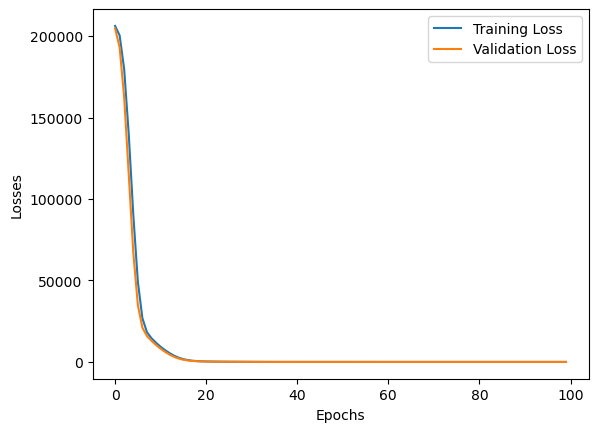

In [20]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [21]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [22]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.44440460205078
Testing MSE: 18.77385711669922


In [23]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9343902076612678


In [24]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.268280,433.27
1,436.537811,438.16
2,461.280029,458.42
3,476.112732,480.82
4,435.412201,441.41
...,...,...
1909,451.040771,456.70
1910,431.391815,438.04
1911,467.722809,467.80
1912,430.800507,437.14
